In [1]:
import pandas as pd
from scripts.aux_msa_functions import *
from scipy.spatial.distance import cdist
import os
import numpy as np
import torch
from Bio import Phylo
import seaborn as sns
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
import re
from scipy.stats import pearsonr
from math import floor,ceil
from scipy import stats
import esm

torch.set_grad_enabled(False)

In [3]:
pfam_metadata = pd.read_csv("./data/pfam-metadata/pfam_metadata.tsv", delimiter = "\t")

all_metrics_dataframe = pd.read_csv("./sequence_scores_table.tsv", delimiter = "\t")
all_metrics_dataframe = all_metrics_dataframe.merge(pfam_metadata, left_on = "family", right_on="pfam_id")



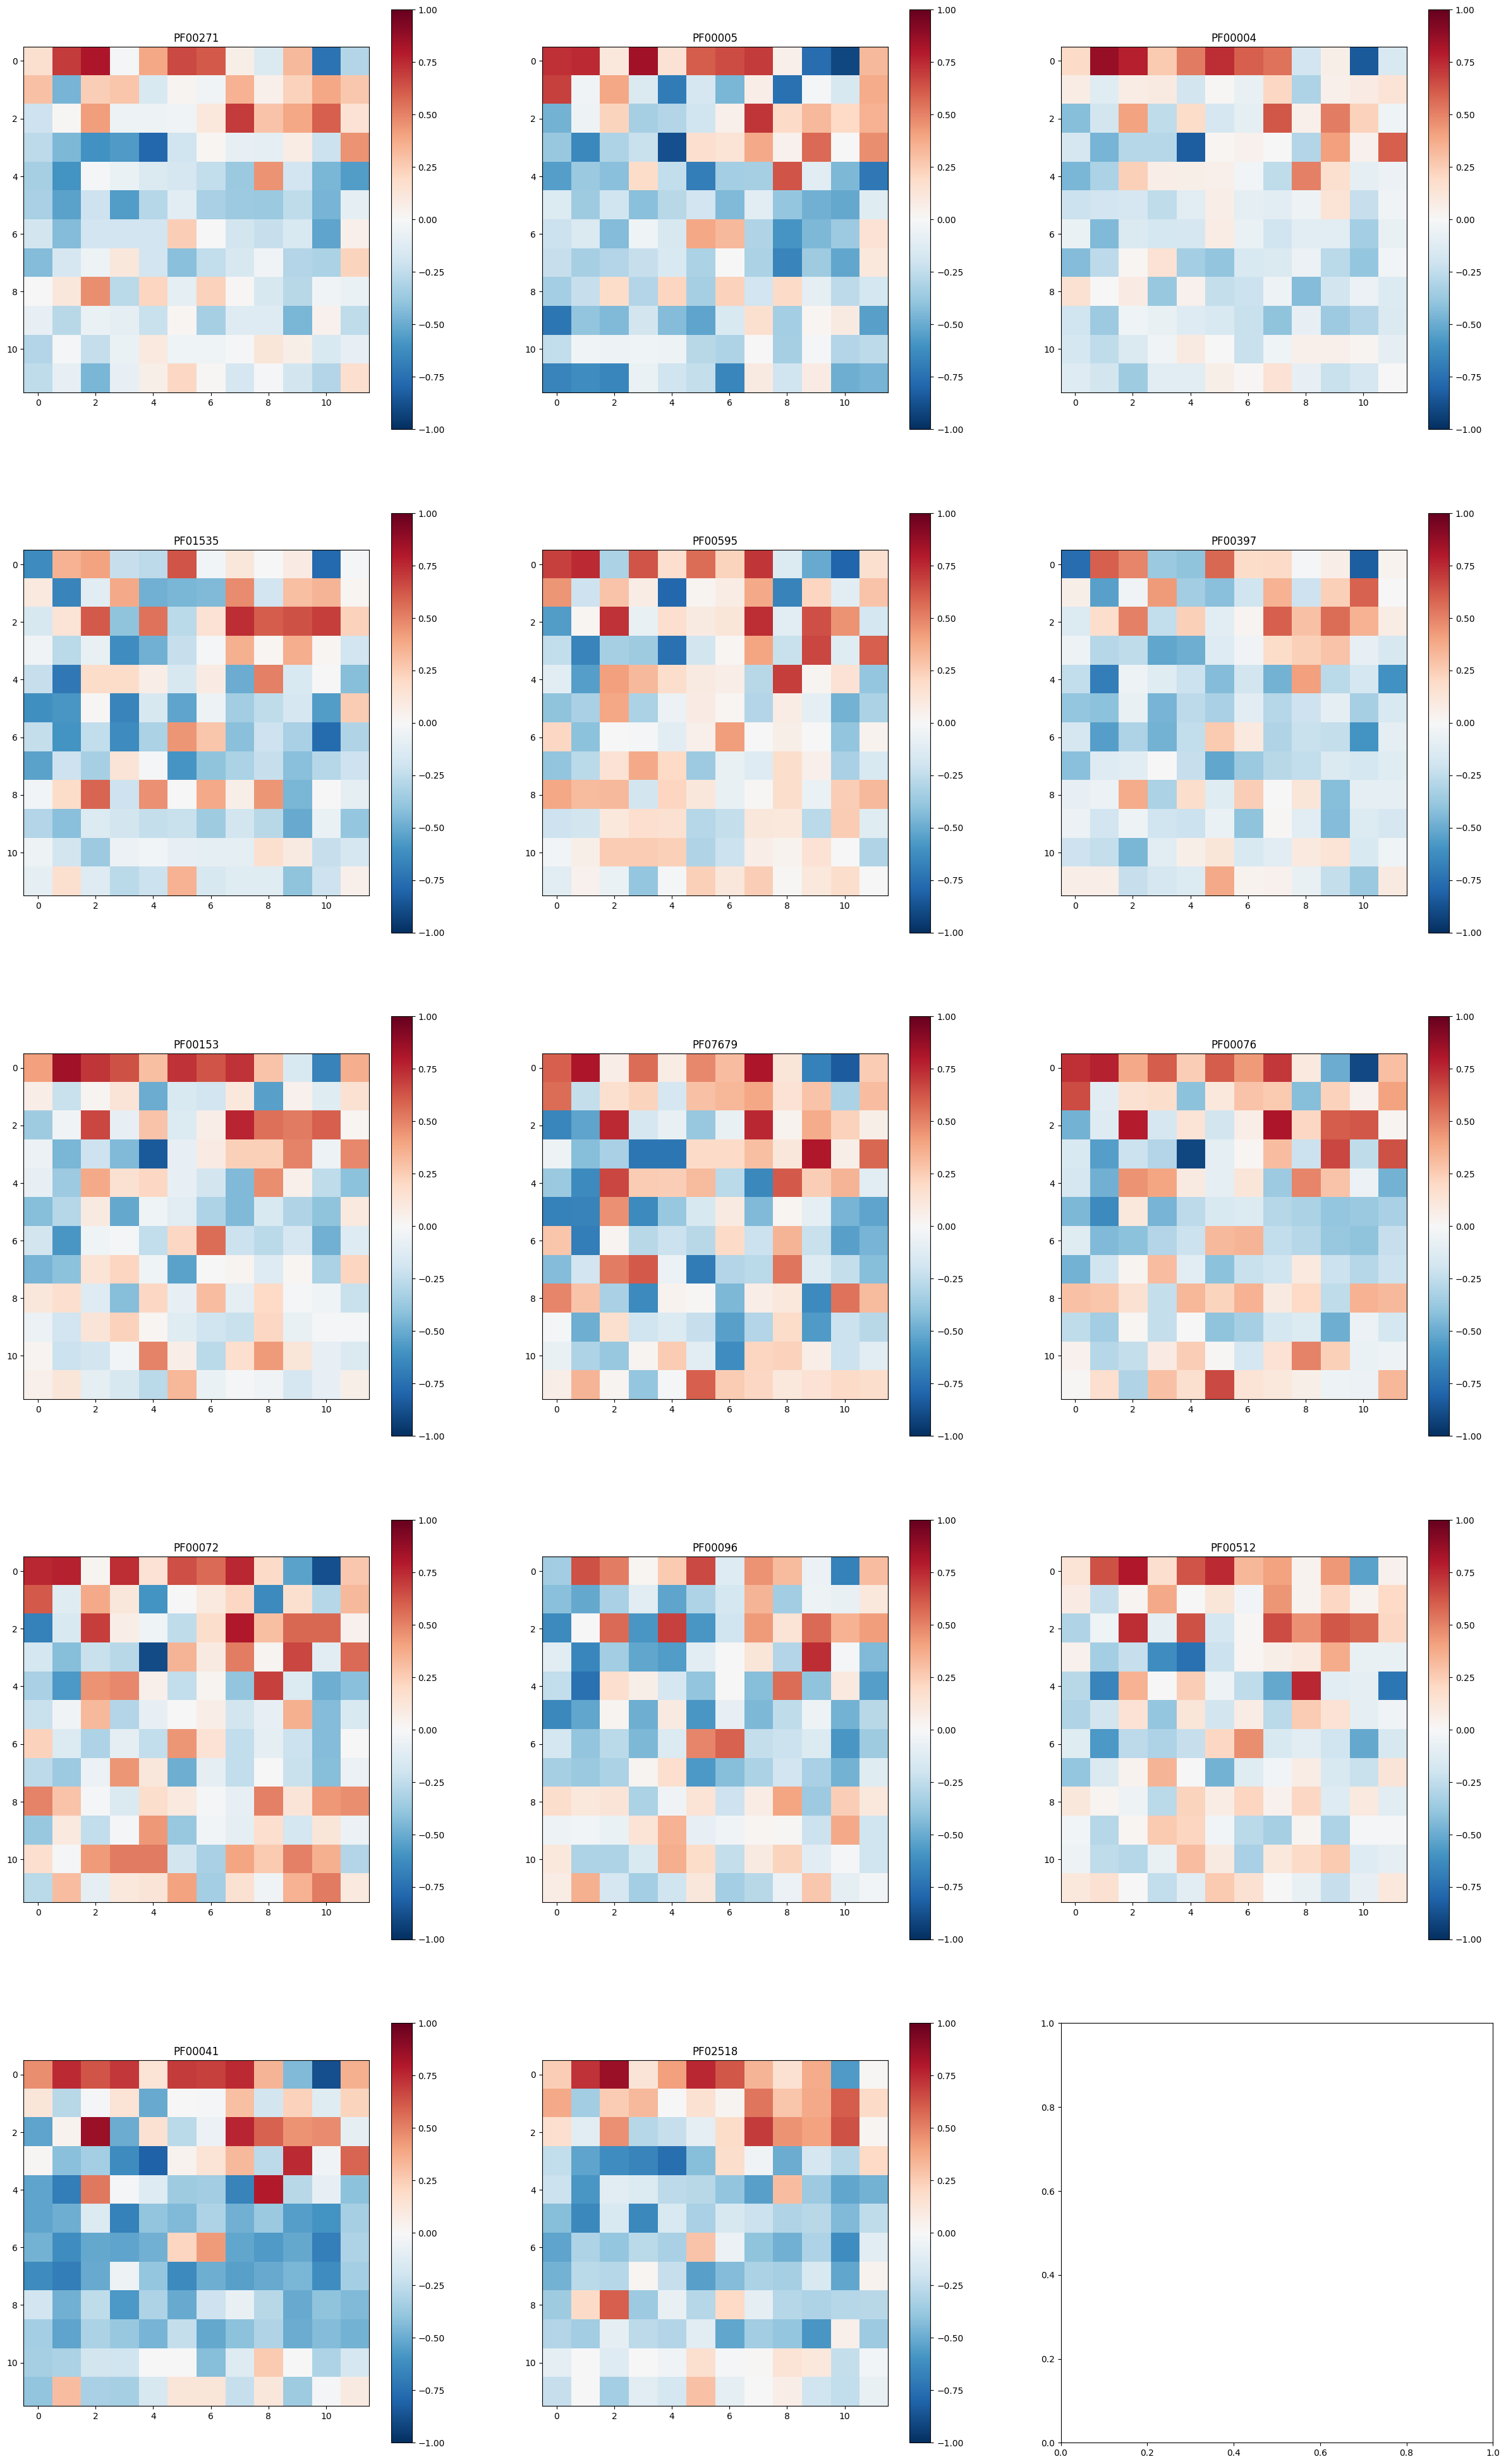

In [4]:
family = "PF00004"
sim_ind = 1
tool = "MSA-1b-logitsprop-static-10-init-seq-0"

families = list(all_metrics_dataframe["family"].unique())
sim_inds = list(range(1,11))

device = "cuda:1"

model, alphabet = esm.pretrained.esm_msa1b_t12_100M_UR50S()
batch_converter = alphabet.get_batch_converter()
model = model.to(device)
model.eval() 

ncols = 3
nrows = max(2,int(ceil((len(families))/3)))

fig, axes = plt.subplots(nrows = nrows, ncols = ncols, figsize = (30,10 * nrows))

corr_matrix_hmmer_list = []
corr_matrix_stat_list = []
corr_matrix_plddt_list = []
corr_matrix_nat_dist_list = []
corr_matrix_self_dist_list = []
corr_matrix_rmsd_list = []

for k, family in enumerate(families):

    torch.cuda.empty_cache()

    all_metrics_dataframe_fam = all_metrics_dataframe.loc[(all_metrics_dataframe["pfam_id"] == family) & 
                                                      (all_metrics_dataframe["sim_ind"] == sim_ind) &
                                                      (all_metrics_dataframe["tool"] == tool), :].reset_index(drop = True)

    i = floor(k/3)
    j = k % 3


    if len(all_metrics_dataframe_fam) > 500:
        # random_ind = list(np.random.choice(range(len(all_metrics_dataframe_fam)),500, replace = False))
        all_metrics_dataframe_fam = all_metrics_dataframe_fam.iloc[:500, :].reset_index(drop = True)

    sequences = [(name, seq) for name, seq in zip(all_metrics_dataframe_fam["sequence_name"], all_metrics_dataframe_fam["sequence"])]
    device = "cuda:1" if torch.cuda.is_available() else "cpu"

    _,_, sequences_tensor = batch_converter([sequences])
    sequences_tensor = sequences_tensor.to(device)

    model_output = model(sequences_tensor, need_head_weights=True)
    column_attns = model_output["col_attentions"][0]

    n_seqs = len(sequences)
    mean_attn = torch.mean(column_attns, axis = [3])

    del model_output, sequences_tensor, column_attns
    torch.cuda.empty_cache()

    mean_attn = torch.mean(mean_attn, axis = [2]).cpu().numpy()
    mean_attn = np.reshape(mean_attn, newshape = (-1,n_seqs), order = 'C')
    mean_attn = np.transpose(mean_attn)

    mean_attn_df = pd.DataFrame(mean_attn, columns = [f"col_attn_{i}" for i in range(mean_attn.shape[1])])
    final_df = pd.concat([mean_attn_df, all_metrics_dataframe_fam], axis = 1)

    corr_matrix_hmmer = np.zeros(144)
    corr_matrix_stat = np.zeros(144)
    corr_matrix_plddt = np.zeros(144)
    corr_matrix_nat_dist = np.zeros(144)
    corr_matrix_self_dist = np.zeros(144)
    corr_matrix_rmsd = np.zeros(144)

    for a in range(len(corr_matrix_hmmer)):

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["hmmer_seq_score"]).statistic
        corr_matrix_hmmer[a] = corr

        try:
            corr = pearsonr(final_df[f"col_attn_{a}"], final_df["stat_energy_scores"]).statistic
            corr_matrix_stat[a] = corr
        except:
            pass

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["plddt_scores"]).statistic
        corr_matrix_plddt[a] = corr

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["min_natural_ham_dist_seed"]).statistic
        corr_matrix_nat_dist[a] = corr

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["max_self_ham_distance"]).statistic
        corr_matrix_self_dist[a] = corr

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["rmsd"]).statistic
        corr_matrix_rmsd[a] = corr

    corr_matrix_hmmer = np.reshape(corr_matrix_hmmer, newshape = (12,12), order = "C")
    corr_matrix_stat = np.reshape(corr_matrix_stat, newshape = (12,12), order = "C")
    corr_matrix_plddt = np.reshape(corr_matrix_plddt, newshape = (12,12), order = "C")
    corr_matrix_nat_dist = np.reshape(corr_matrix_nat_dist, newshape = (12,12), order = "C")
    corr_matrix_self_dist = np.reshape(corr_matrix_self_dist, newshape = (12,12), order = "C")
    corr_matrix_rmsd = np.reshape(corr_matrix_rmsd, newshape = (12,12), order = "C")

    corr_matrix_hmmer_list.append(corr_matrix_hmmer)
    corr_matrix_stat_list.append(corr_matrix_stat)
    corr_matrix_plddt_list.append(corr_matrix_plddt)
    corr_matrix_nat_dist_list.append(corr_matrix_nat_dist)
    corr_matrix_self_dist_list.append(corr_matrix_self_dist)
    corr_matrix_rmsd_list.append(corr_matrix_rmsd)

    im = axes[i][j].imshow(corr_matrix_hmmer, vmin = -1, vmax = 1, cmap = "RdBu_r")
    plt.colorbar(im, ax=axes[i][j])
    axes[i][j].set_title(f"{family}")


In [5]:
mean_hmmer_corr = np.stack(corr_matrix_hmmer_list).mean(axis=0)
mean_stat_corr = np.stack(corr_matrix_stat_list).mean(axis=0)
mean_plddt_corr = np.stack(corr_matrix_plddt_list).mean(axis=0)
mean_nat_dist_corr = np.stack(corr_matrix_nat_dist_list).mean(axis=0)
mean_self_dist_corr = np.stack(corr_matrix_self_dist_list).mean(axis=0)
mean_rmsd_corr = np.stack(corr_matrix_rmsd_list).mean(axis=0)

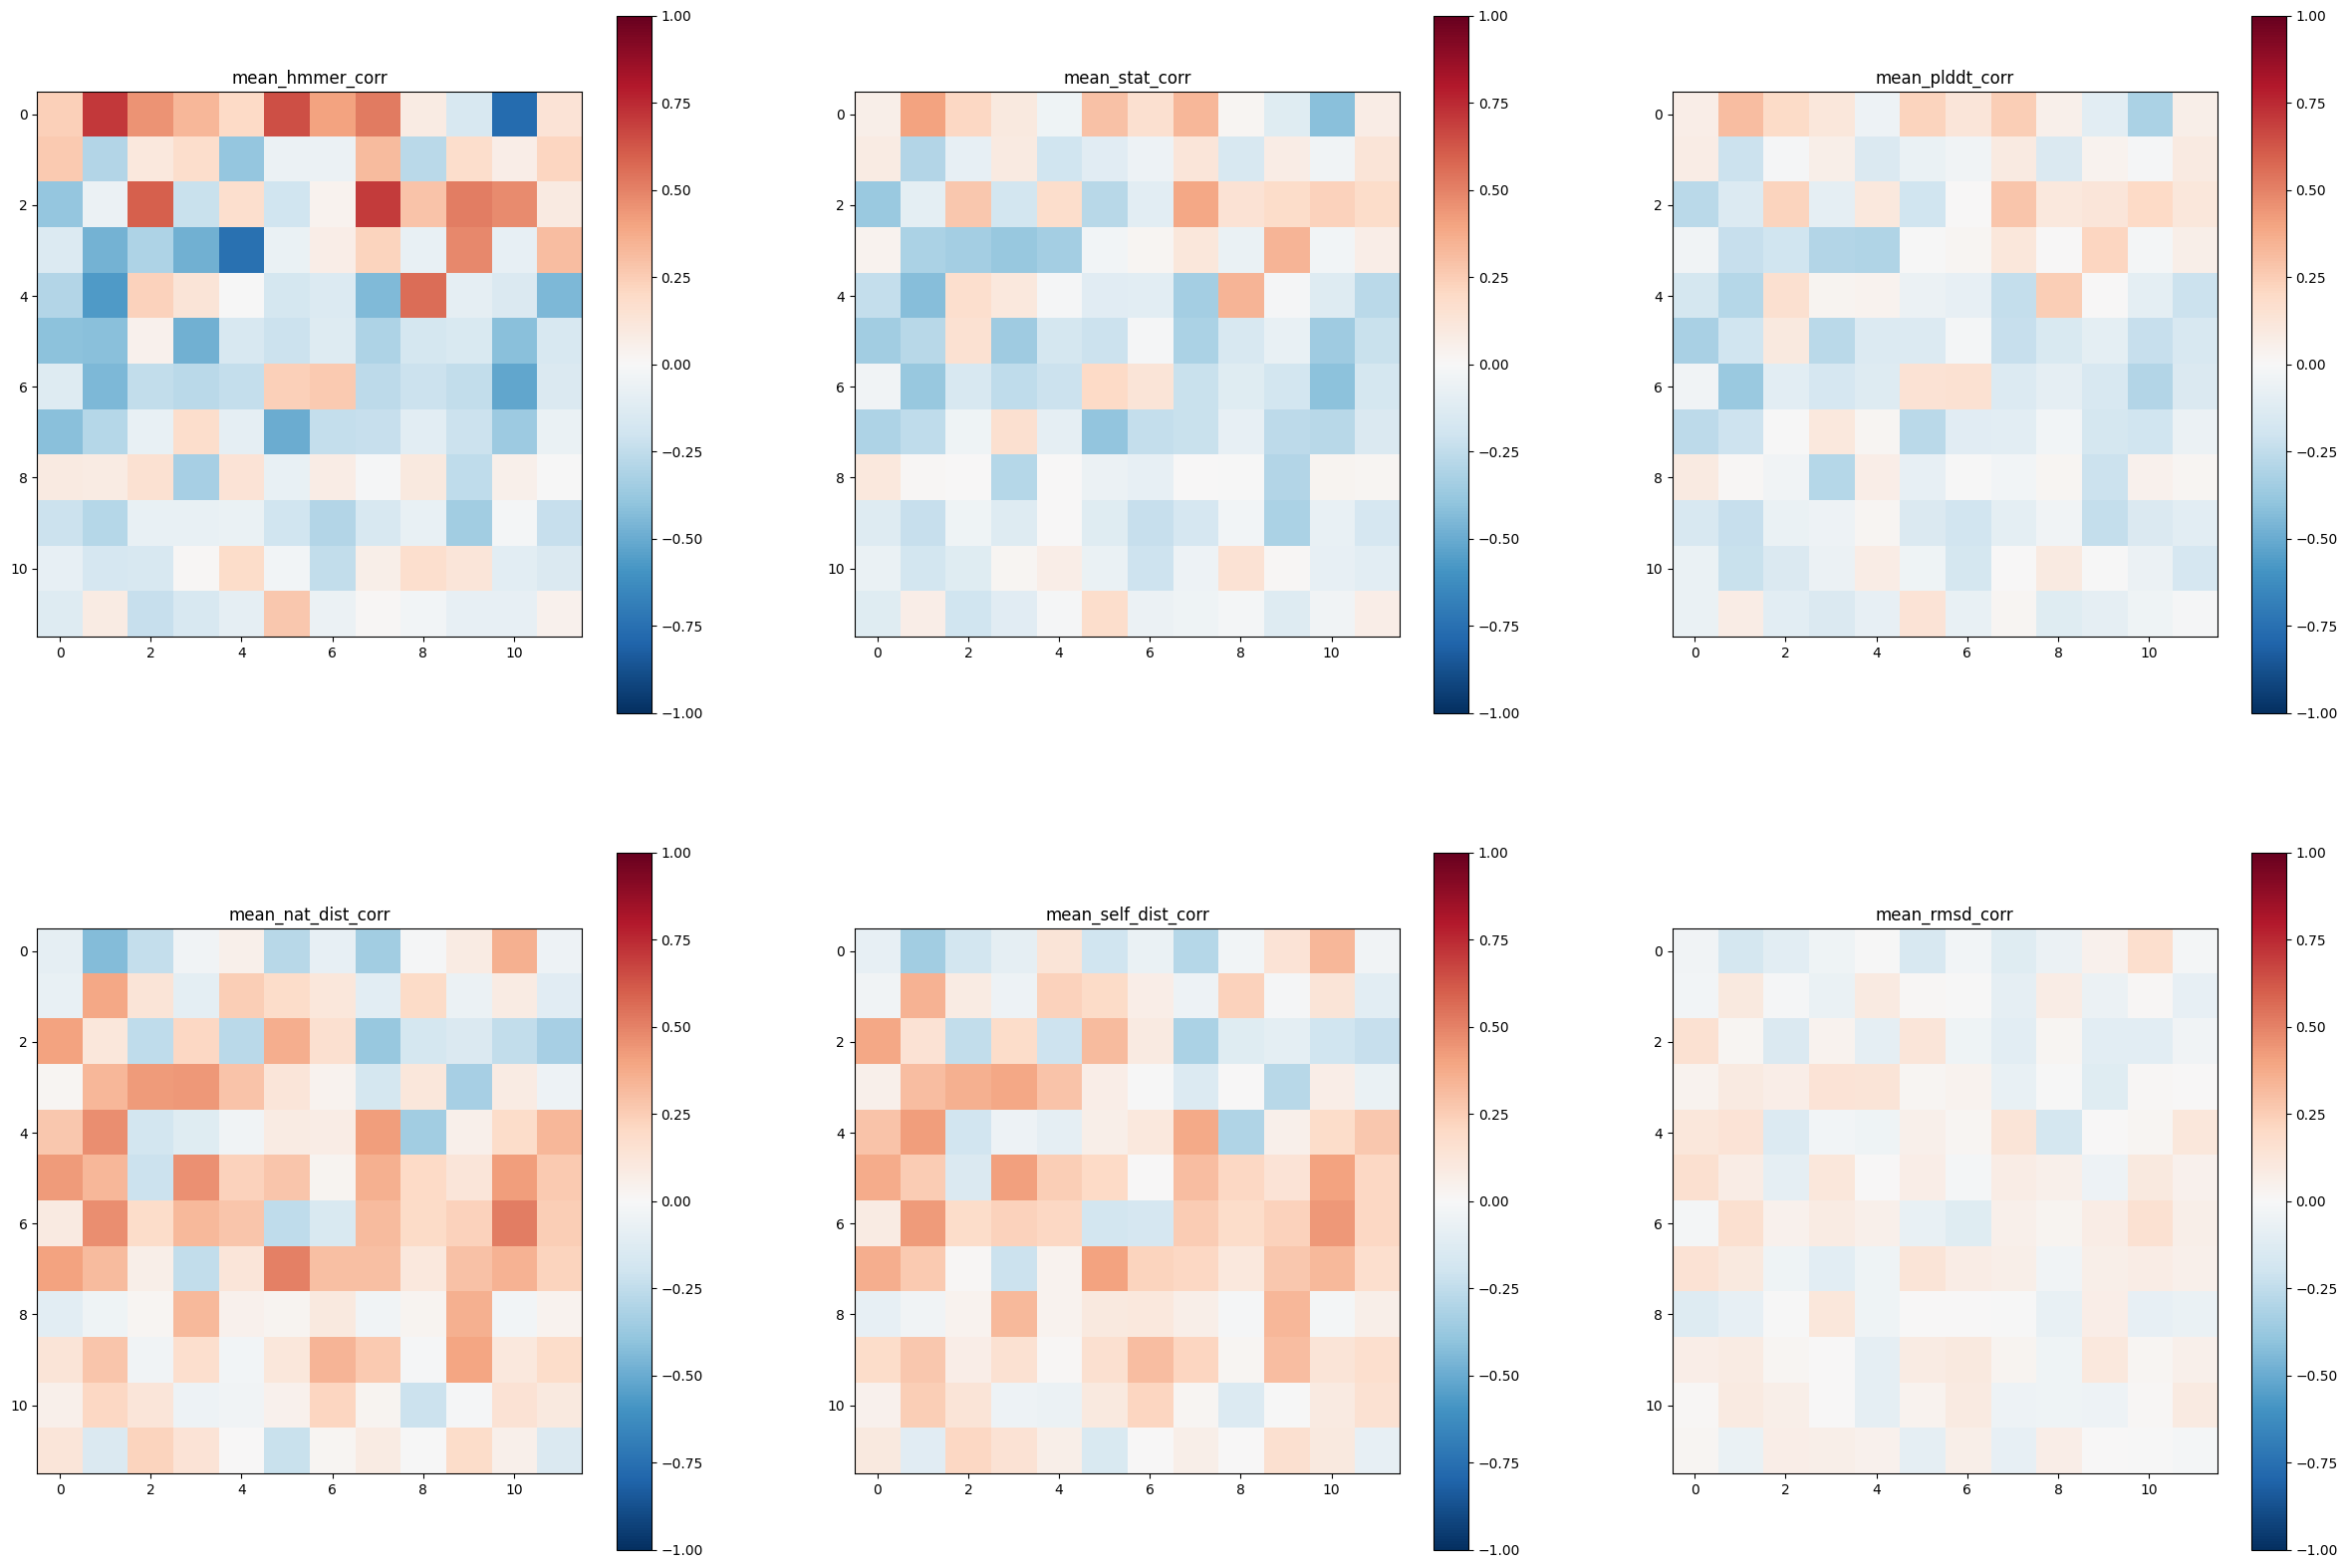

In [6]:

fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (30,20))

im = axes[0][0].imshow(mean_hmmer_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[0][0])
axes[0][0].set_title(f"mean_hmmer_corr")

im = axes[0][1].imshow(mean_stat_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[0][1])
axes[0][1].set_title(f"mean_stat_corr")

im = axes[0][2].imshow(mean_plddt_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[0][2])
axes[0][2].set_title(f"mean_plddt_corr")

im = axes[1][0].imshow(mean_nat_dist_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[1][0])
axes[1][0].set_title(f"mean_nat_dist_corr")

im = axes[1][1].imshow(mean_self_dist_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[1][1])
axes[1][1].set_title(f"mean_self_dist_corr")

im = axes[1][2].imshow(mean_rmsd_corr, vmin = -1, vmax = 1, cmap = "RdBu_r")
plt.colorbar(im, ax=axes[1][2])
axes[1][2].set_title(f"mean_rmsd_corr")

plt.savefig("column_attn_corrs_all_metrics.jpeg")


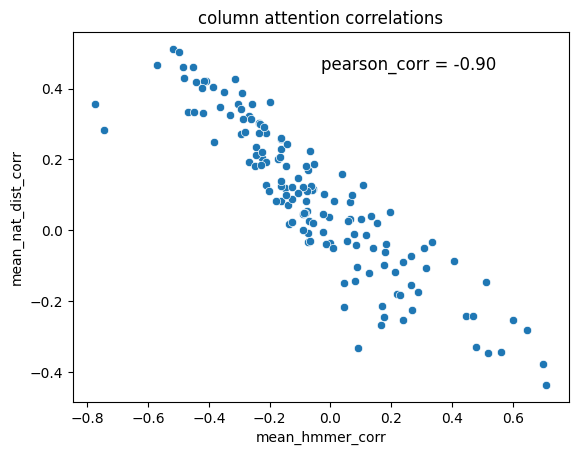

In [10]:
sns.scatterplot(x =mean_hmmer_corr.flatten(), y=mean_nat_dist_corr.flatten())
plt.xlabel("mean_hmmer_corr")
plt.ylabel("mean_nat_dist_corr")
plt.title("column attention correlations")

pearson_corr = pearsonr(x =mean_hmmer_corr.flatten(), y=mean_nat_dist_corr.flatten())
plt.annotate(f"pearson_corr = {pearson_corr.statistic:.2f}",xy = (0.5,0.9), xycoords = "axes fraction", fontsize = 12)

plt.savefig("column_attn_scatter_hmmer_vs_nat_dist.jpeg")

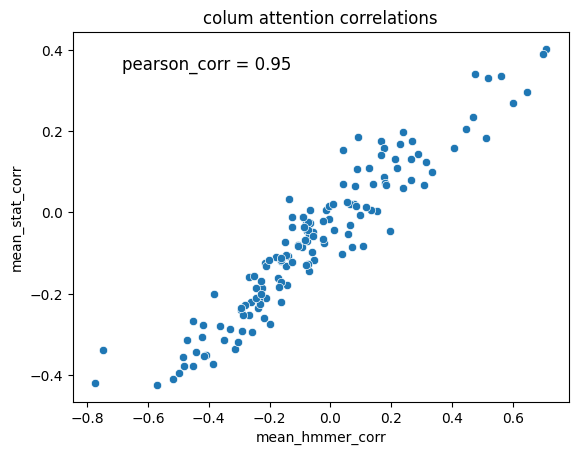

In [11]:
sns.scatterplot(x =mean_hmmer_corr.flatten(), y=mean_stat_corr.flatten())
plt.xlabel("mean_hmmer_corr")
plt.ylabel("mean_stat_corr")
plt.title("colum attention correlations")

pearson_corr = pearsonr(x =mean_hmmer_corr.flatten(), y=mean_stat_corr.flatten())
plt.annotate(f"pearson_corr = {pearson_corr.statistic:.2f}",xy = (0.1,0.9), xycoords = "axes fraction", fontsize = 12)

plt.savefig("column_attn_scatter_hmmer_vs_stat.jpeg")

### ESM2 Attentions

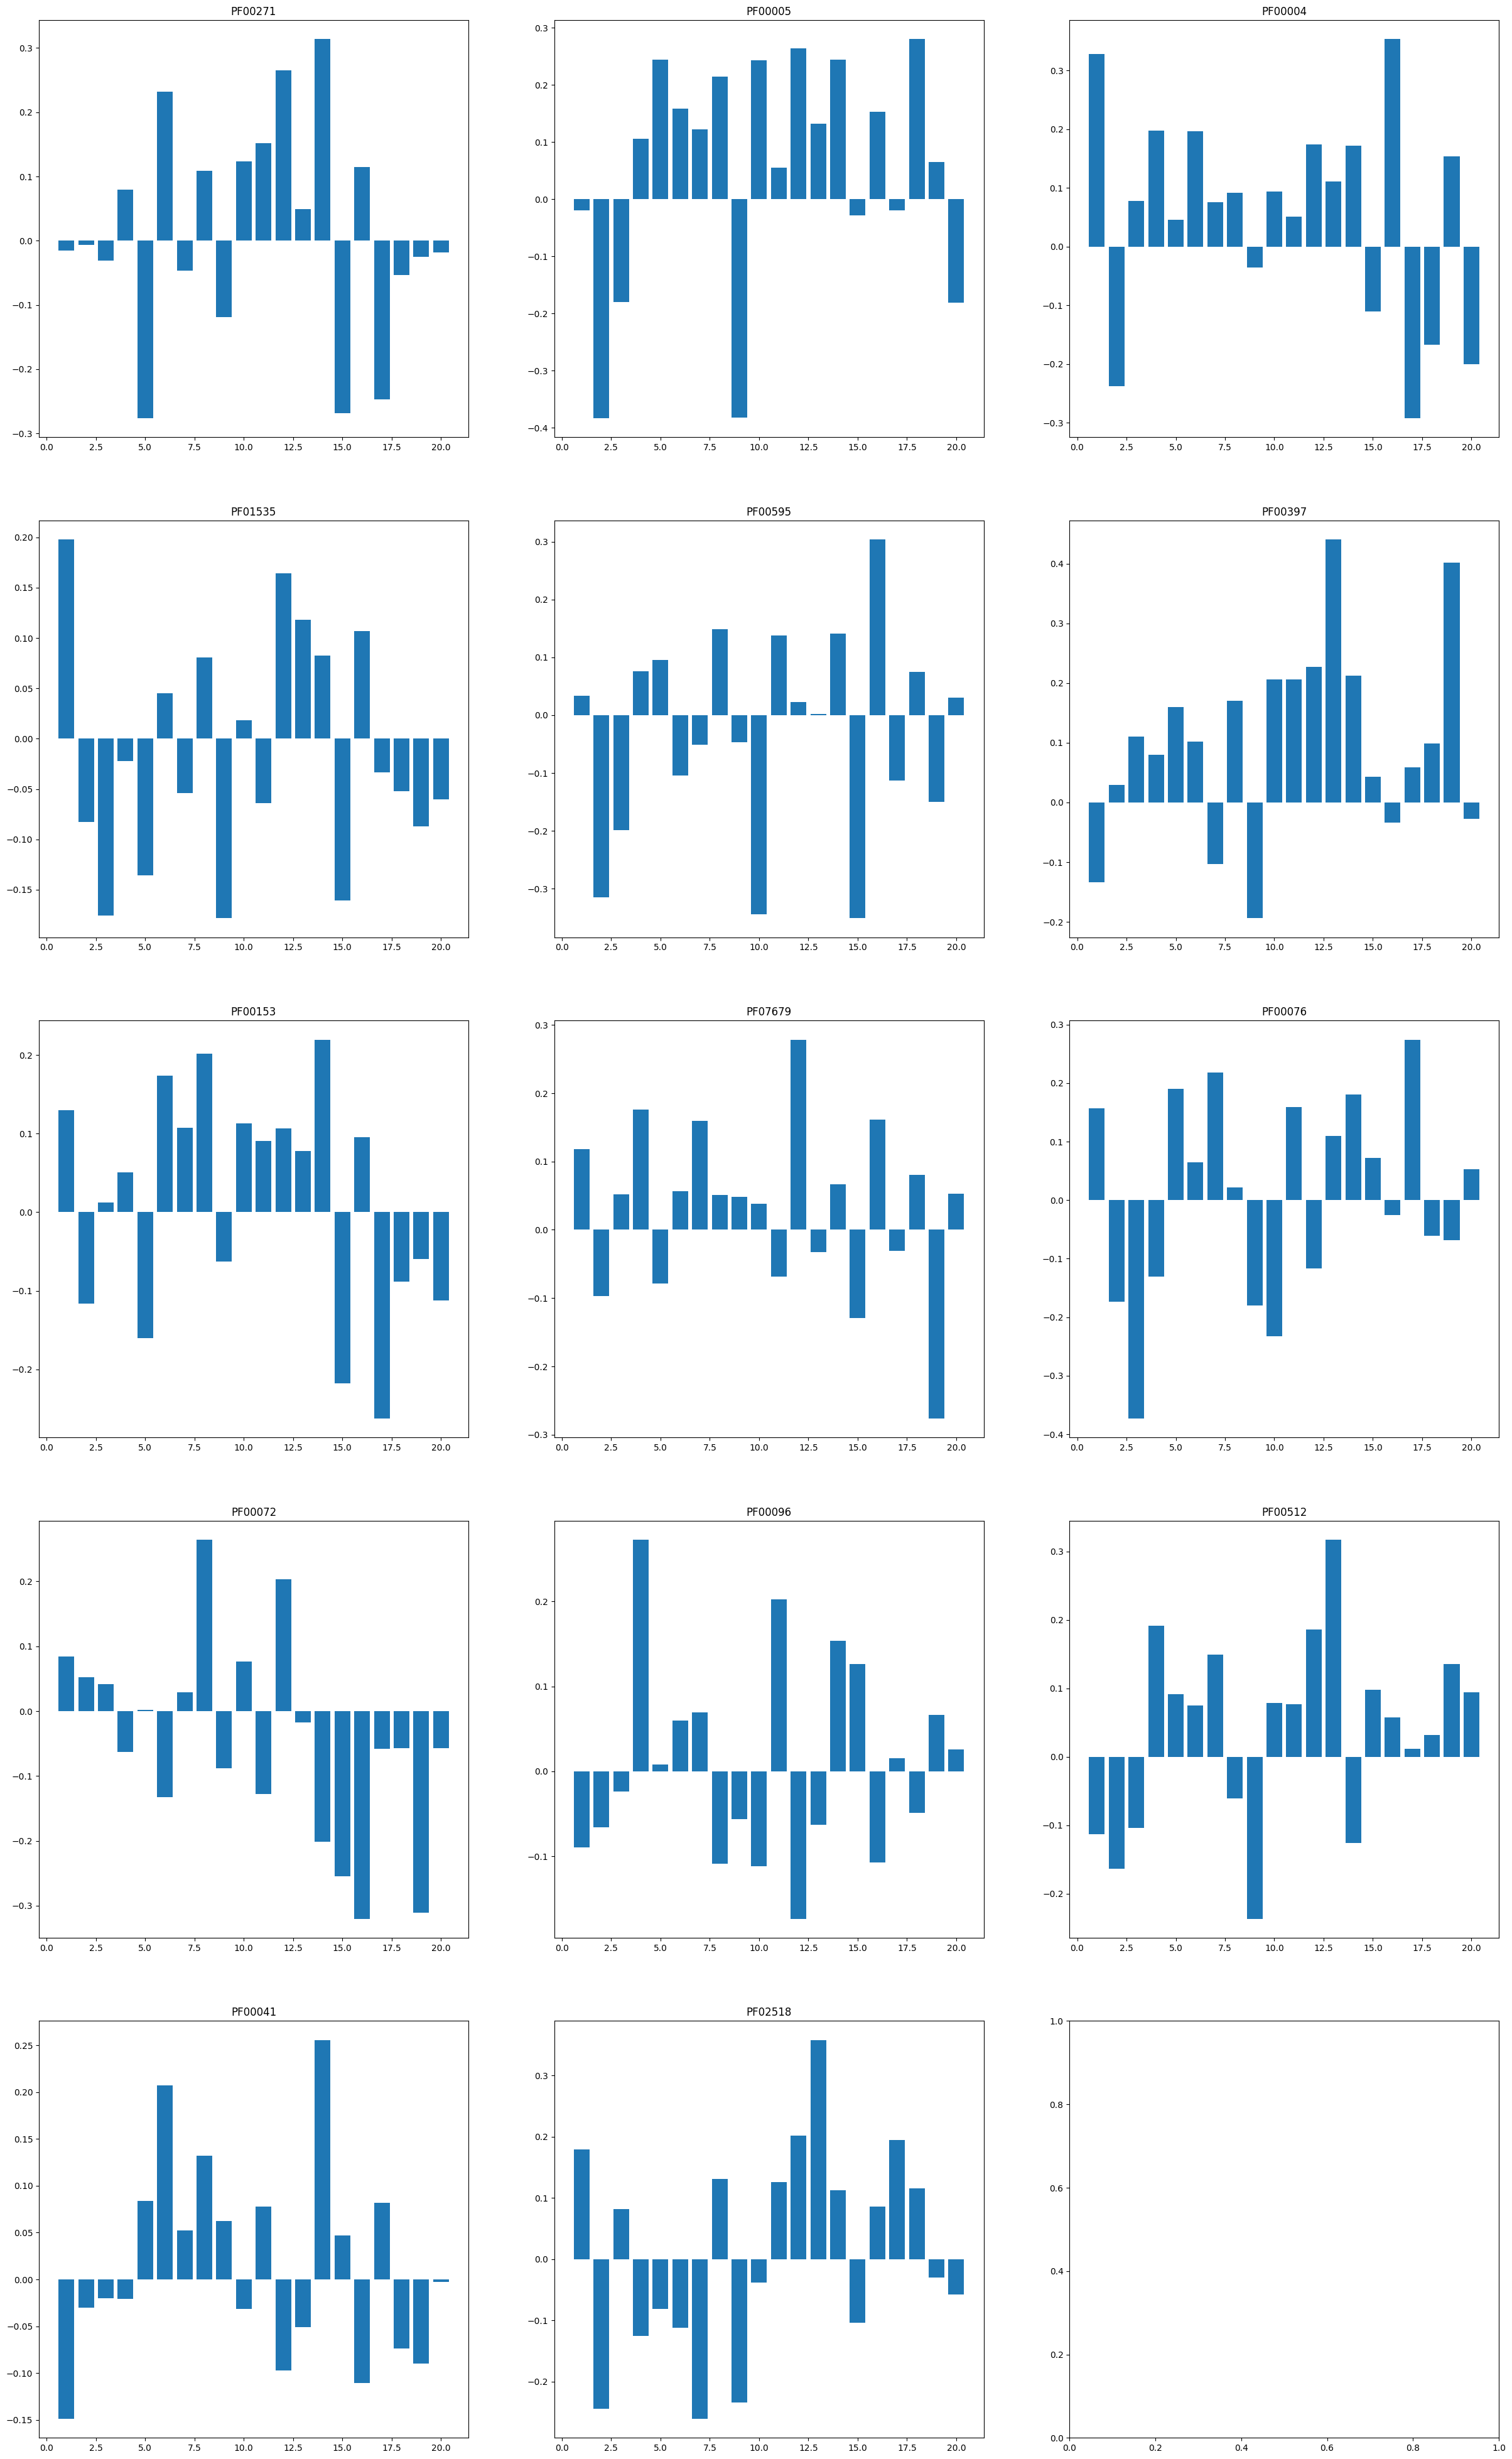

In [42]:
family = "PF00004"
sim_ind = 1
tool = "MSA-1b-logitsprop-static-10-init-seq-0"

families = list(all_metrics_dataframe["family"].unique())
sim_inds = list(range(1,11))

device = "cuda:1"

from transformers import EsmForMaskedLM, EsmTokenizer

model_name = "facebook/esm2_t33_650M_UR50D"
tokenizer = EsmTokenizer.from_pretrained(model_name)
model = EsmForMaskedLM.from_pretrained(model_name, output_attentions=True)
model = model.to(device)

model.eval()

ncols = 3
nrows = max(2,int(ceil((len(families))/3)))

fig, axes = plt.subplots(nrows = nrows, ncols = ncols, figsize = (30,10 * nrows))

corr_matrix_hmmer_list = []
corr_matrix_stat_list = []
corr_matrix_plddt_list = []
corr_matrix_nat_dist_list = []
corr_matrix_self_dist_list = []
corr_matrix_rmsd_list = []

for k, family in enumerate(families):

    torch.cuda.empty_cache()

    all_metrics_dataframe_fam = all_metrics_dataframe.loc[(all_metrics_dataframe["pfam_id"] == family) & 
                                                      (all_metrics_dataframe["sim_ind"] == sim_ind) &
                                                      (all_metrics_dataframe["tool"] == tool), :].reset_index(drop = True)

    i = floor(k/3)
    j = k % 3


    sequences = list(all_metrics_dataframe_fam["sequence"])
    device = "cuda:1" if torch.cuda.is_available() else "cpu"

    inputs = tokenizer(sequences, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    attentions = outputs.attentions[0]

    # max_attn = attentions.mean(axis = [2]).max(axis = 2).values.cpu().numpy()
    mean_attn = attentions.mean(axis = [2])

    def entropy(x, dim=-1, eps=1e-12):
    # Normalize to make it a probability distribution
        p = x / (x.sum(dim=dim, keepdim=True) + eps)

        # Avoid log(0) by adding small epsilon
        log_p = torch.log(p + eps)

        # Compute entropy: -sum(p * log(p))
        H = - (p * log_p).sum(dim=dim)
        return H

    entropy_attn = entropy(mean_attn, dim=2).cpu().numpy()

    del outputs, inputs, attentions
    torch.cuda.empty_cache()

    max_attn_df = pd.DataFrame(entropy_attn, columns = [f"col_attn_{i}" for i in range(entropy_attn.shape[1])])
    final_df = pd.concat([max_attn_df, all_metrics_dataframe_fam], axis = 1)

    corr_matrix_hmmer = np.zeros(20)
    corr_matrix_stat = np.zeros(20)
    corr_matrix_plddt = np.zeros(20)
    corr_matrix_nat_dist = np.zeros(20)
    corr_matrix_self_dist = np.zeros(20)
    corr_matrix_rmsd = np.zeros(20)

    for a in range(len(corr_matrix_hmmer)):

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["hmmer_seq_score"]).statistic
        corr_matrix_hmmer[a] = corr

        try:
            corr = pearsonr(final_df[f"col_attn_{a}"], final_df["stat_energy_scores"]).statistic
            corr_matrix_stat[a] = corr
        except:
            pass

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["plddt_scores"]).statistic
        corr_matrix_plddt[a] = corr

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["min_natural_ham_dist_seed"]).statistic
        corr_matrix_nat_dist[a] = corr

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["max_self_ham_distance"]).statistic
        corr_matrix_self_dist[a] = corr

        corr = pearsonr(final_df[f"col_attn_{a}"], final_df["rmsd"]).statistic
        corr_matrix_rmsd[a] = corr

    corr_matrix_hmmer_list.append(corr_matrix_hmmer)
    corr_matrix_stat_list.append(corr_matrix_stat)
    corr_matrix_plddt_list.append(corr_matrix_plddt)
    corr_matrix_nat_dist_list.append(corr_matrix_nat_dist)
    corr_matrix_self_dist_list.append(corr_matrix_self_dist)
    corr_matrix_rmsd_list.append(corr_matrix_rmsd)

    axes[i][j].bar(x = range(1,21), height = corr_matrix_hmmer)
    axes[i][j].set_title(f"{family}")

In [43]:
mean_hmmer_corr = np.stack(corr_matrix_hmmer_list).mean(axis=0)
mean_stat_corr = np.stack(corr_matrix_stat_list).mean(axis=0)
mean_plddt_corr = np.stack(corr_matrix_plddt_list).mean(axis=0)
mean_nat_dist_corr = np.stack(corr_matrix_nat_dist_list).mean(axis=0)
mean_self_dist_corr = np.stack(corr_matrix_self_dist_list).mean(axis=0)
mean_rmsd_corr = np.stack(corr_matrix_rmsd_list).mean(axis=0)

Text(0.5, 1.0, 'mean_rmsd_corr')

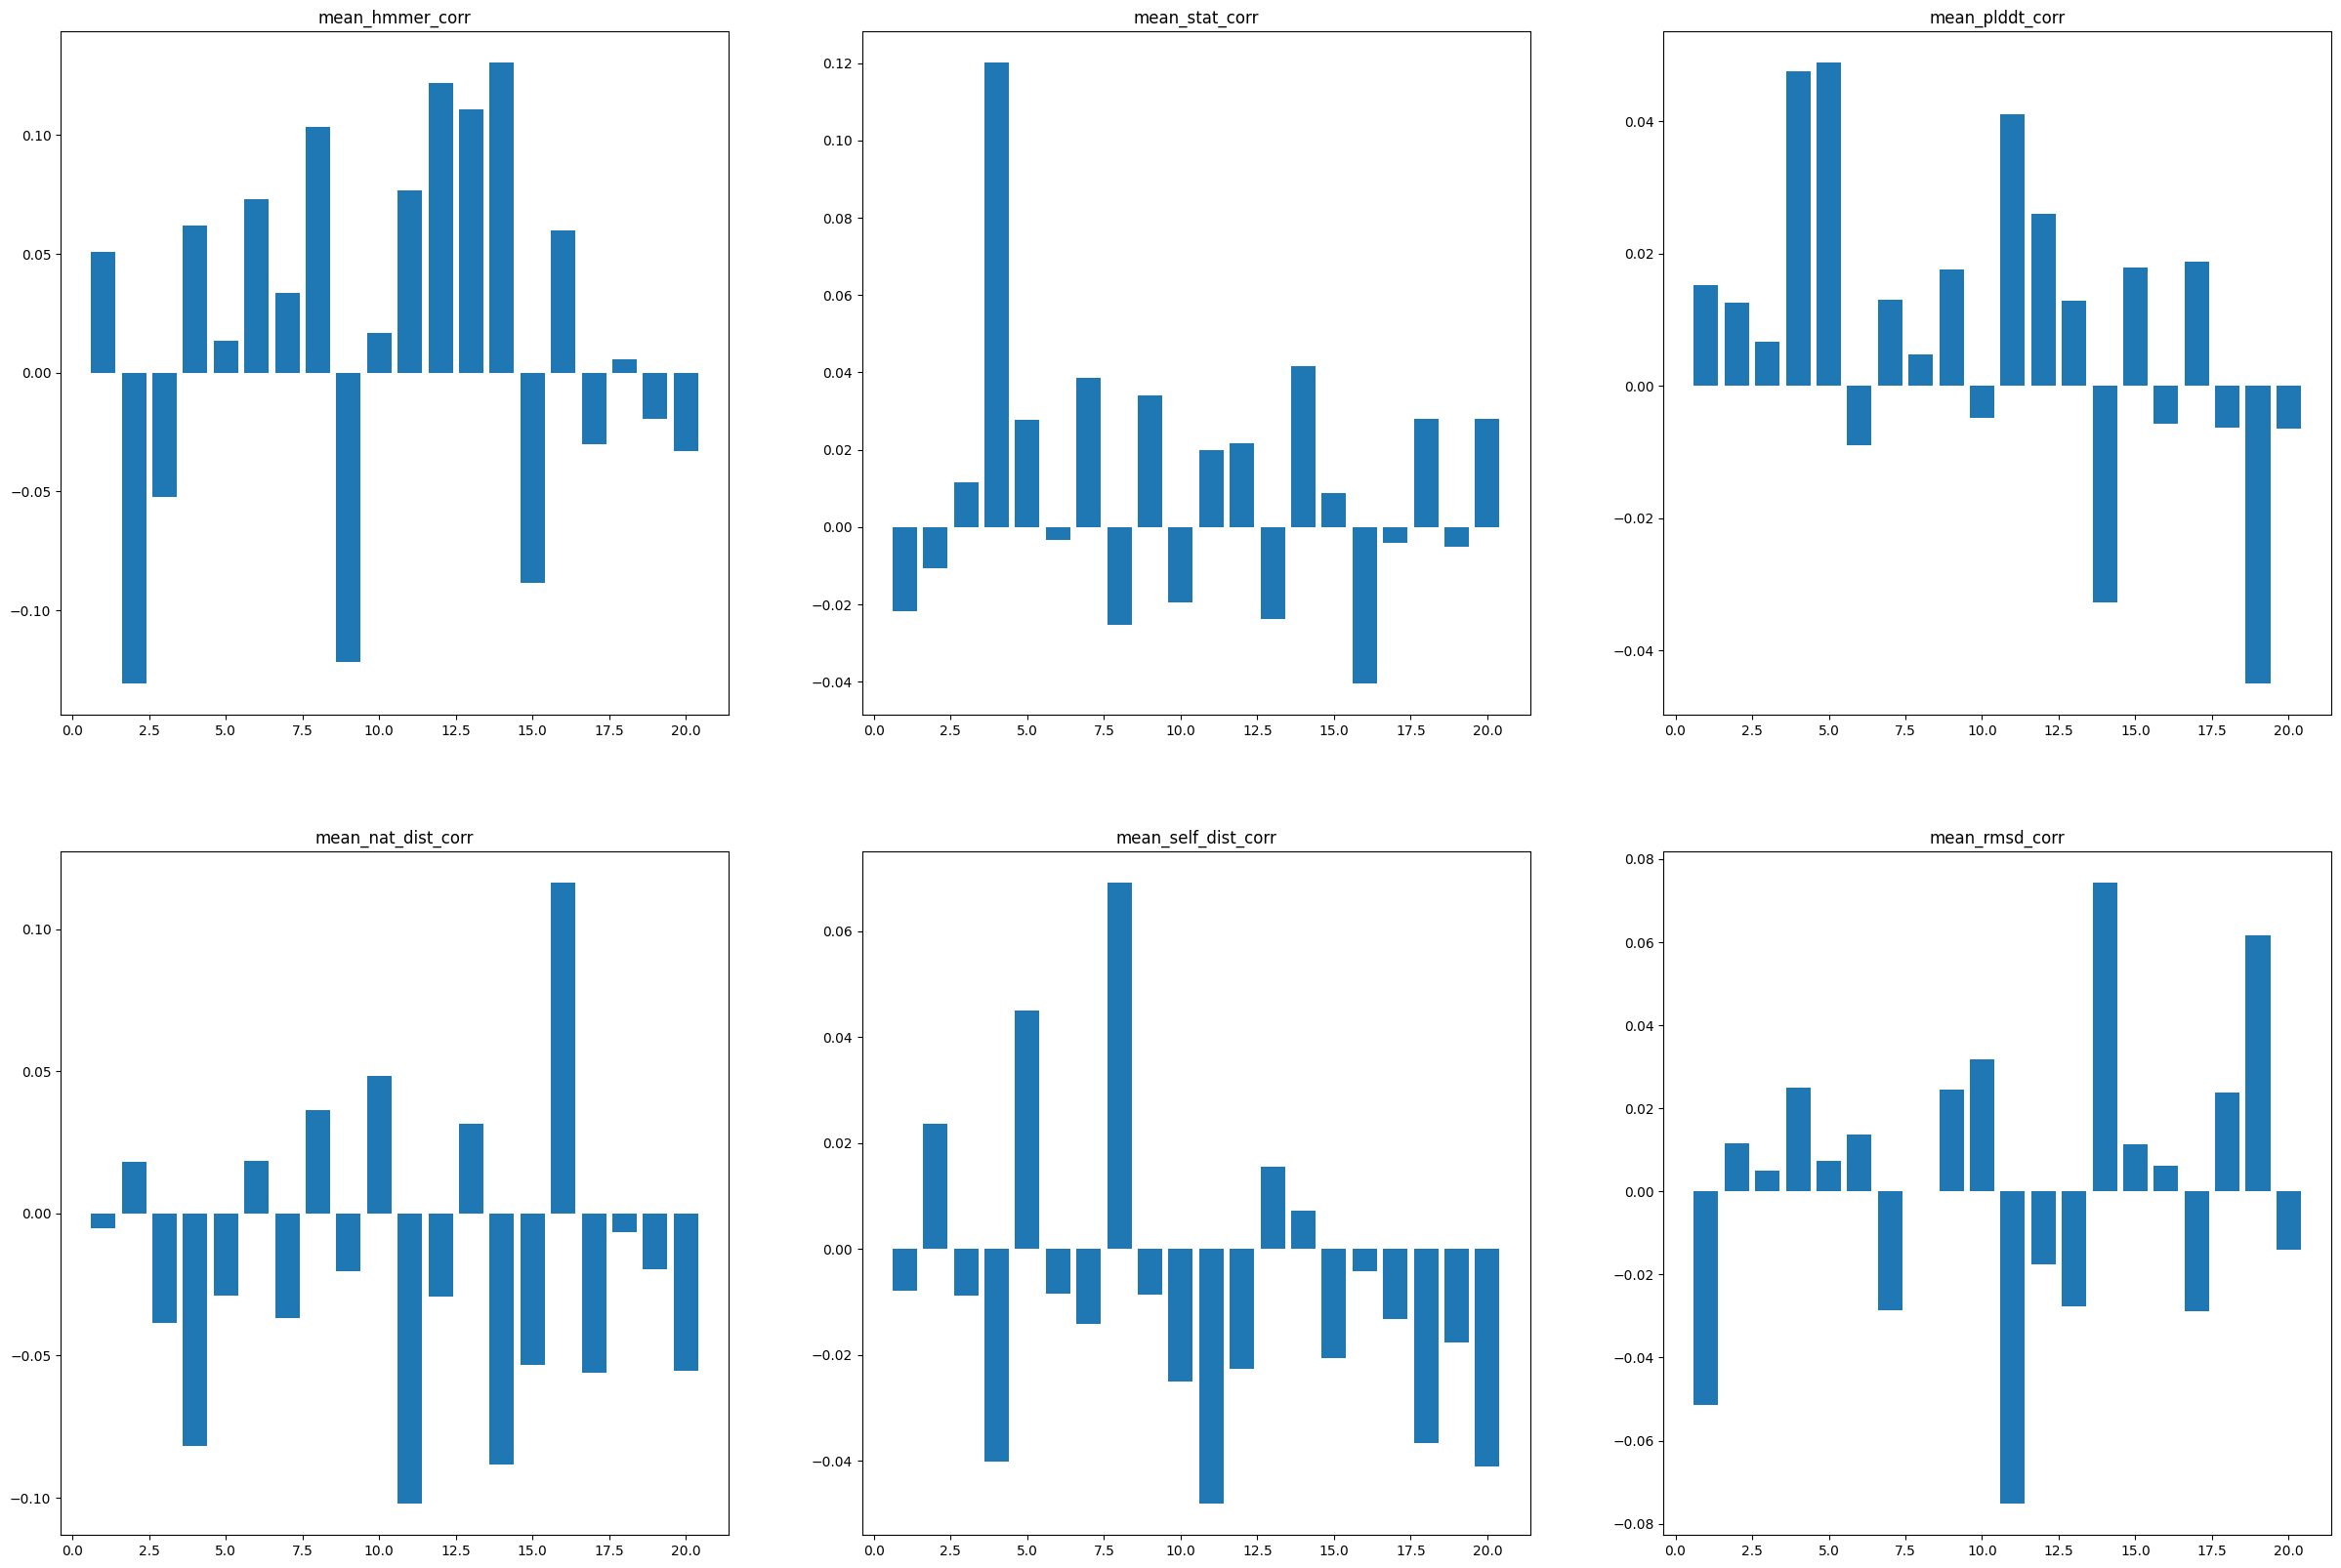

In [44]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (30,20))

axes[0][0].bar(x = range(1,21), height = mean_hmmer_corr)
axes[0][0].set_title(f"mean_hmmer_corr")

axes[0][1].bar(x = range(1,21), height = mean_stat_corr)
axes[0][1].set_title(f"mean_stat_corr")

axes[0][2].bar(x = range(1,21), height = mean_plddt_corr)
axes[0][2].set_title(f"mean_plddt_corr")

axes[1][0].bar(x = range(1,21), height = mean_nat_dist_corr)
axes[1][0].set_title(f"mean_nat_dist_corr")

axes[1][1].bar(x = range(1,21), height = mean_self_dist_corr)
axes[1][1].set_title(f"mean_self_dist_corr")

axes[1][2].bar(x = range(1,21), height = mean_rmsd_corr)
axes[1][2].set_title(f"mean_rmsd_corr")